# Autoencoders (PyTorch)

In this lab, you will build: Autoencoders, denoising autoencoder, and convolutional autoencoders

# Learning Objectives

By the end of this lab, you should be able to:

- explain what an autoencoder is
- understand the role of the encoder and decoder
- interpret the bottleneck or latent representation
- train a simple dense autoencoder
- train a denoising autoencoder
- train a convolutional autoencoder
- compare reconstruction quality across different architectures

# Introduction

**Autoencoders** are a particular type of neural network that compresses the data into a **latent vector**, often denoted $z$ in the literature, with the goal of preserving the opportunity to recreate the exact same image in the future.

Because autoencoders learn representations instead of labels, they belong to **representation learning**, a subfield of machine learning, but not necessarily deep learning.

## Architecture

Autoencoders consist of two networks:

- an **encoder**, which compresses the input
- a **decoder**, which reconstructs the input from the compressed representation

This notebook explores three versions:
1. a simple dense autoencoder
2. a denoising autoencoder
3. a convolutional autoencoder

# Step 1 — Notebook Setup

We start with the PyTorch equivalent of the original environment setup and imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
Using device: cuda


# Step 2 — Loading the Data

We load MNIST, but without labels, because representation learning is **unsupervised**, or **self-supervised**, which is the preferred term.


In [2]:
# Load MNIST and normalize pixel values
train_dataset_raw = datasets.MNIST(root="./data", train=True, download=True)
test_dataset_raw = datasets.MNIST(root="./data", train=False, download=True)

x_train = train_dataset_raw.data.numpy() / 255.0
x_test = test_dataset_raw.data.numpy() / 255.0

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.7MB/s]


x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


# Part 1 — A Simple Autoencoder

We begin with the simplest possible autoencoder.

The `encoder` is a sequential neural network with $28 \times 28$ input neurons, $100$ neurons in the second layer and $30$ in the third.

The third layer is called the **bottleneck**.  
Feel free to play around with this variable to see how it affects the results.

In [3]:
# Simple dense encoder
class SimpleEncoder(nn.Module):
    def __init__(self, bottleneck_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 100),
            nn.ReLU(),
            nn.Linear(100, bottleneck_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

encoder = SimpleEncoder(bottleneck_dim=30).to(device)
print(encoder)
total_params = sum(p.numel() for p in encoder.parameters())
print(f"Total parameters: {total_params:,}")

SimpleEncoder(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=30, bias=True)
    (4): ReLU()
  )
)
Total parameters: 81,530


The decoder is the same, but in reverse order.

Note that in Keras the decoder needs to know the input shape at this point (`input_shape=[30]`). In PyTorch this is implicit: `nn.Linear(30, 100)` already fixes the expected input dimension.  
The input shape of the decoder is the shape of $z$, also called `zDim` in some implementations.

In [4]:
# Simple dense decoder
class SimpleDecoder(nn.Module):
    def __init__(self, bottleneck_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bottleneck_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.net(x)
        return x.view(-1, 28, 28)

decoder = SimpleDecoder(bottleneck_dim=30).to(device)
print(decoder)
total_params = sum(p.numel() for p in decoder.parameters())
print(f"Total parameters: {total_params:,}")

SimpleDecoder(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=784, bias=True)
    (3): Sigmoid()
  )
)
Total parameters: 82,284


Now we stack the encoder and decoder together for training.

In [5]:
# Full simple autoencoder
class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

stacked_autoencoder = Autoencoder(encoder, decoder).to(device)
total_params = sum(p.numel() for p in stacked_autoencoder.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 163,814


We use **binary cross entropy** instead of categorical cross entropy.

The reason is that we are not classifying latent vectors into classes.  
Instead, the network is trying to reconstruct pixel values, that is, whether a pixel should be activated or not.

Since the decoder already applies a `Sigmoid` at its output, we use `nn.BCELoss` (which expects probabilities), not `nn.BCEWithLogitsLoss` (which expects raw logits).

In [6]:
# Compile the autoencoder
criterion = nn.BCELoss()
optimizer = optim.Adam(stacked_autoencoder.parameters())

Notice how the input and the target are the same:

- input = `x_train`
- target = `x_train`

This is the basic principle of autoencoder training.

In [7]:
def train_autoencoder(model, x_train_data, x_train_target, x_val_data, x_val_target,
                       criterion, optimizer, device, epochs=10, batch_size=32):
    train_dataset = TensorDataset(torch.tensor(x_train_data), torch.tensor(x_train_target))
    val_dataset = TensorDataset(torch.tensor(x_val_data), torch.tensor(x_val_target))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    history = {"loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            total += xb.size(0)
        train_loss = running_loss / total

        model.eval()
        val_running_loss = 0.0
        val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_running_loss += loss.item() * xb.size(0)
                val_total += xb.size(0)
        val_loss = val_running_loss / val_total

        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

    return history


# Train the simple autoencoder
history = train_autoencoder(stacked_autoencoder, x_train, x_train, x_test, x_test,
                             criterion, optimizer, device, epochs=10)

Epoch 1/10 - loss: 0.1650 - val_loss: 0.1209
Epoch 2/10 - loss: 0.1124 - val_loss: 0.1046
Epoch 3/10 - loss: 0.1026 - val_loss: 0.0985
Epoch 4/10 - loss: 0.0982 - val_loss: 0.0958
Epoch 5/10 - loss: 0.0958 - val_loss: 0.0939
Epoch 6/10 - loss: 0.0943 - val_loss: 0.0928
Epoch 7/10 - loss: 0.0932 - val_loss: 0.0920
Epoch 8/10 - loss: 0.0923 - val_loss: 0.0911
Epoch 9/10 - loss: 0.0917 - val_loss: 0.0907
Epoch 10/10 - loss: 0.0910 - val_loss: 0.0898


Let's now look at how the autoencoder reconstructs images.

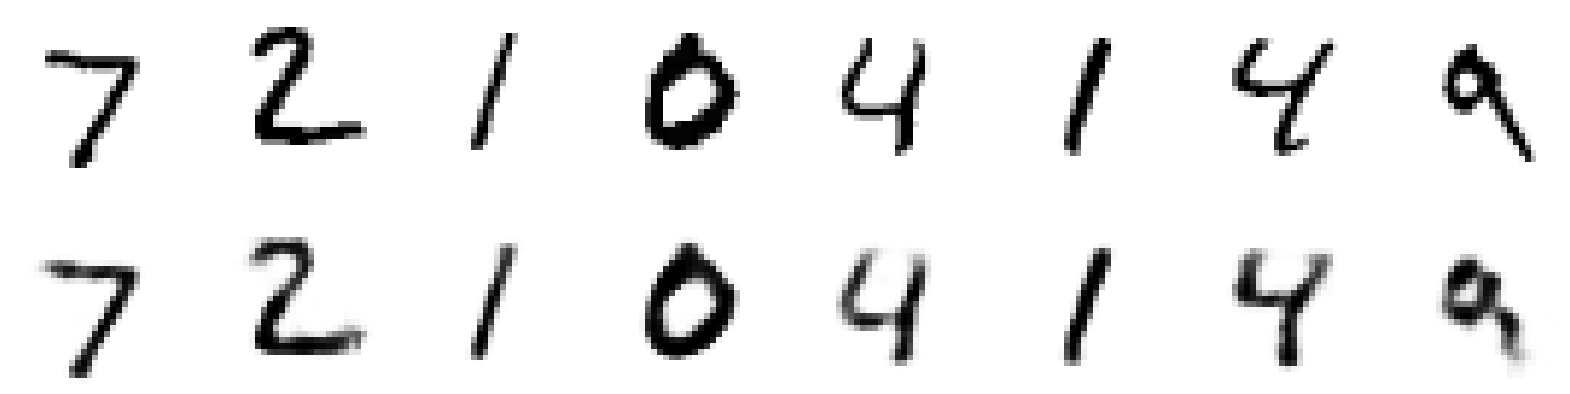

In [ ]:
stacked_autoencoder.eval()

plt.figure(figsize=(20, 5))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    with torch.no_grad():
        inp = torch.tensor(x_test[i]).reshape(1, 28, 28).to(device)
        pred = stacked_autoencoder(inp).cpu().numpy()
    plt.imshow(x_test[i], cmap="binary")
    plt.axis("off")

    plt.subplot(2, 8, i + 8 + 1)
    plt.imshow(pred.reshape((28, 28)), cmap="binary")
    plt.axis("off")
plt.show()

We can also inspect how much information is stored in the bottleneck representation.

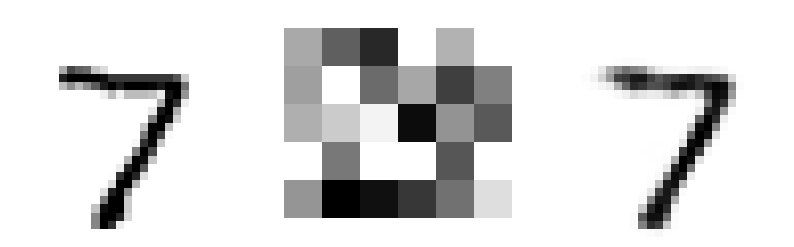

In [ ]:
i = 0  # change this number

plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(x_test[i], cmap="binary")
plt.axis("off")

with torch.no_grad():
    inp = torch.tensor(x_test[i]).reshape(1, 28, 28).to(device)
    z = encoder(inp).cpu().numpy()
    recon = decoder(torch.tensor(z).to(device)).cpu().numpy()

plt.subplot(1, 3, 2)
plt.imshow(z.reshape((5, 6)), cmap="binary")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(recon.reshape((28, 28)), cmap="binary")
plt.axis("off")
plt.show()

In [ ]:
30 / (28 * 28), 1 - 30 / (28 * 28)

(0.03826530612244898, 0.9617346938775511)

That's **96.2% compression** — pretty amazing.

# Part 2 — Denoising Autoencoder

The next application we explore is the **denoising autoencoder**.

The idea is simple:
- corrupt the input image with noise
- ask the autoencoder to reconstruct the original clean image

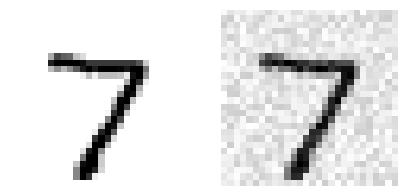

In [ ]:
# Show an example of a clean image and a noisy version
plt.figure(figsize=(5, 10))
plt.subplot(1, 2, 1)
plt.imshow(x_test[0], cmap="binary")
plt.axis("off")

plt.subplot(1, 2, 2)
noise = np.random.random((28, 28)) / 4
plt.imshow(x_test[0] + noise, cmap="binary")
plt.axis("off")
plt.show()

In machine learning, this kind of noise can be catastrophic.  
Luckily, autoencoders can be trained to remove it.

By applying noise to the images fed into the encoder and keeping the clean image as the desired output, the autoencoder can learn a denoising transformation.

Let's build such an autoencoder.

In [ ]:
# Denoising encoder
class DenoisingEncoder(nn.Module):
    def __init__(self, bottleneck_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, bottleneck_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

encoder = DenoisingEncoder(bottleneck_dim=30).to(device)
print(encoder)

DenoisingEncoder(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=30, bias=True)
    (6): ReLU()
  )
)


In [ ]:
# Denoising decoder
class DenoisingDecoder(nn.Module):
    def __init__(self, bottleneck_dim=30):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bottleneck_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 28 * 28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.net(x)
        return x.view(-1, 28, 28)

decoder = DenoisingDecoder(bottleneck_dim=30).to(device)
print(decoder)

DenoisingDecoder(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [14]:
# Full denoising autoencoder
stacked_autoencoder = Autoencoder(encoder, decoder).to(device)
total_params = sum(p.numel() for p in stacked_autoencoder.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 184,014


In [15]:
# Compile the denoising autoencoder
criterion = nn.BCELoss()
optimizer = optim.Adam(stacked_autoencoder.parameters())

Now create noisy versions of the dataset.

In [16]:
# Add random noise to the images
x_train_noise = x_train + ((np.random.random(x_train.shape)) / 4).astype("float32")
x_test_noise = x_test + ((np.random.random(x_test.shape)) / 4).astype("float32")

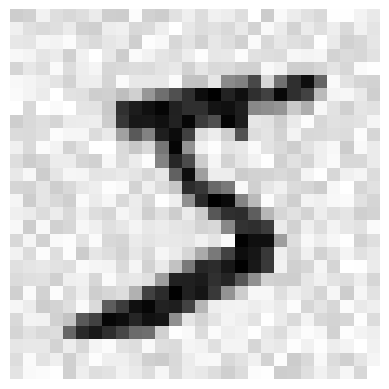

In [17]:
plt.imshow(x_train_noise[0], cmap="binary")
plt.axis("off")
plt.show()

And finally train the denoising autoencoder with:
- noisy input images
- clean target images

In [18]:
# Train on noisy inputs and clean targets
history = train_autoencoder(stacked_autoencoder, x_train_noise, x_train, x_test_noise, x_test,
                             criterion, optimizer, device, epochs=10)

Epoch 1/10 - loss: 0.2061 - val_loss: 0.1536
Epoch 2/10 - loss: 0.1456 - val_loss: 0.1349
Epoch 3/10 - loss: 0.1300 - val_loss: 0.1237
Epoch 4/10 - loss: 0.1223 - val_loss: 0.1184
Epoch 5/10 - loss: 0.1184 - val_loss: 0.1156
Epoch 6/10 - loss: 0.1151 - val_loss: 0.1122
Epoch 7/10 - loss: 0.1122 - val_loss: 0.1097
Epoch 8/10 - loss: 0.1102 - val_loss: 0.1082
Epoch 9/10 - loss: 0.1088 - val_loss: 0.1077
Epoch 10/10 - loss: 0.1077 - val_loss: 0.1063


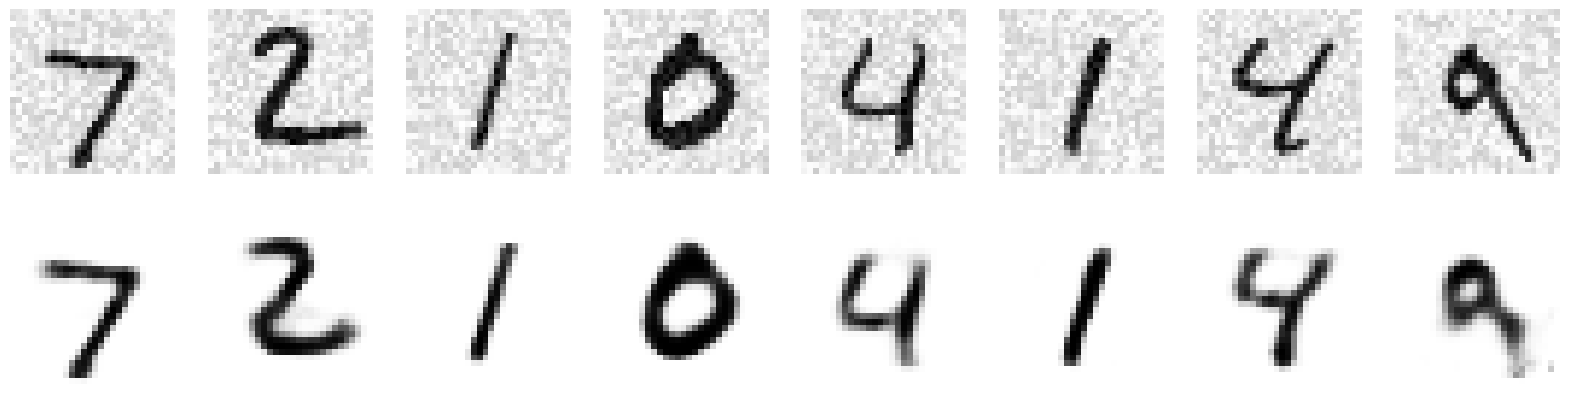

In [ ]:
# Compare noisy inputs and denoised outputs
stacked_autoencoder.eval()

plt.figure(figsize=(20, 5))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(x_test_noise[i], cmap="binary")
    plt.axis("off")

    plt.subplot(2, 8, i + 8 + 1)
    with torch.no_grad():
        inp = torch.tensor(x_test_noise[i]).reshape(1, 28, 28).to(device)
        pred = stacked_autoencoder(inp).cpu().numpy()
    plt.imshow(pred.reshape((28, 28)), cmap="binary")
    plt.axis("off")
plt.show()

Mindblowing!

# Part 3 — Convolutional Autoencoder

Apart from data compression, autoencoders can also be used for self-supervised image representation learning.

In this last part, we switch from dense layers to **convolutional layers**, which are usually much better suited to images because they preserve spatial structure.

Let's first build a convolutional encoder.

In [ ]:
# Convolutional encoder
class ConvEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

    def forward(self, x):
        # x: (N, 28, 28) -> add channel dimension -> (N, 1, 28, 28)
        x = x.unsqueeze(1)
        return self.net(x)

encoder = ConvEncoder().to(device)
print(encoder)
total_params = sum(p.numel() for p in encoder.parameters())
print(f"Total parameters: {total_params:,}")

ConvEncoder(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)
Total parameters: 23,296


Noise is added again before training the convolutional autoencoder.

In [ ]:
# Add random noise to the images
x_train_noise = x_train + ((np.random.random(x_train.shape)) / 4).astype("float32")
x_test_noise = x_test + ((np.random.random(x_test.shape)) / 4).astype("float32")

# Important: clip back to [0, 1] after adding noise.
# nn.BCELoss requires targets strictly in [0, 1] (it's a Bernoulli log-likelihood);
# without clipping, noisy pixels can exceed 1.0, which raises a CUDA
# "device-side assert triggered" error inside binary_cross_entropy on GPU.
x_train_noise = np.clip(x_train_noise, 0.0, 1.0)
x_test_noise = np.clip(x_test_noise, 0.0, 1.0)

**Build the Convolutional Encoder**

Three convolution + max-pooling blocks progressively reduce the `28 x 28` image down to a `64 x 3 x 3` latent representation (576 values — the bottleneck).

In [ ]:
class ConvEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (N, 28, 28) -> (N, 1, 28, 28)
        return self.net(x)


encoder = ConvEncoder().to(device)
print(encoder)

with torch.no_grad():
    sample_out = encoder(torch.tensor(x_test[0]).reshape(1, 28, 28).to(device))
print("Latent shape:", sample_out.shape)  # (1, 64, 3, 3)

ConvEncoder(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)
Latent shape: torch.Size([1, 64, 3, 3])


**Build the Convolutional Decoder**

We use **transposed convolutions** to go back from `64 x 3 x 3` to `28 x 28`, mirroring the encoder's downsampling with the correct `padding` / `output_padding` so the shapes match exactly (`3 -> 7 -> 14 -> 28`).

In [ ]:
class ConvDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 3x3x64 -> 7x7x32  (Keras Conv2DTranspose(..., padding="valid") equivalent)
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=0), nn.ReLU(),
            # 7x7x32 -> 14x14x16  (Keras Conv2DTranspose(..., padding="same") equivalent)
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(),
            # 14x14x16 -> 28x28x1
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.net(x)
        return x.squeeze(1)  # (N, 1, 28, 28) -> (N, 28, 28)


decoder = ConvDecoder().to(device)
print(decoder)

with torch.no_grad():
    sample_recon = decoder(sample_out)
print("Reconstruction shape:", sample_recon.shape)  # (1, 28, 28)

ConvDecoder(
  (net): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)
Reconstruction shape: torch.Size([1, 28, 28])


**Assemble and Compile the Autoencoder**

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


stacked_autoencoder = Autoencoder(encoder, decoder).to(device)
total_params = sum(p.numel() for p in stacked_autoencoder.parameters())
print(f"Total parameters: {total_params:,}")

criterion = nn.BCELoss()
optimizer = optim.Adam(stacked_autoencoder.parameters())

Total parameters: 46,529


# **Train the Convolutional Autoencoder**

In [ ]:
def train_autoencoder(model, x_train_data, x_train_target, x_val_data, x_val_target,
                       criterion, optimizer, device, epochs=10, batch_size=32):

    def run_training():
        train_dataset = TensorDataset(torch.tensor(x_train_data), torch.tensor(x_train_target))
        val_dataset = TensorDataset(torch.tensor(x_val_data), torch.tensor(x_val_target))
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        history = {"loss": [], "val_loss": []}

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            total = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                outputs = model(xb)
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * xb.size(0)
                total += xb.size(0)
            train_loss = running_loss / total

            model.eval()
            val_running_loss = 0.0
            val_total = 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    outputs = model(xb)
                    loss = criterion(outputs, yb)
                    val_running_loss += loss.item() * xb.size(0)
                    val_total += xb.size(0)
            val_loss = val_running_loss / val_total

            history["loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")

        return history

    try:
        return run_training()
    except RuntimeError as e:
        if "cudnn" in str(e).lower() or "cudnn_status" in str(e).lower():
            print("\n[Warning] cuDNN error detected during training.")
            print("Disabling cuDNN and retrying (this run will be slower but should complete)...\n")
            torch.backends.cudnn.enabled = False
            # Re-run the model's forward pass is fine; weights are untouched, we just resume training.
            return run_training()
        else:
            raise


# Train the convolutional autoencoder
history = train_autoencoder(stacked_autoencoder, x_train, x_train, x_test, x_test,
                             criterion, optimizer, device, epochs=10)

Epoch 1/10 - loss: 0.1202 - val_loss: 0.0848
Epoch 2/10 - loss: 0.0822 - val_loss: 0.0784
Epoch 3/10 - loss: 0.0777 - val_loss: 0.0758
Epoch 4/10 - loss: 0.0754 - val_loss: 0.0736
Epoch 5/10 - loss: 0.0739 - val_loss: 0.0731
Epoch 6/10 - loss: 0.0729 - val_loss: 0.0719
Epoch 7/10 - loss: 0.0721 - val_loss: 0.0712
Epoch 8/10 - loss: 0.0715 - val_loss: 0.0705
Epoch 9/10 - loss: 0.0710 - val_loss: 0.0702
Epoch 10/10 - loss: 0.0706 - val_loss: 0.0698


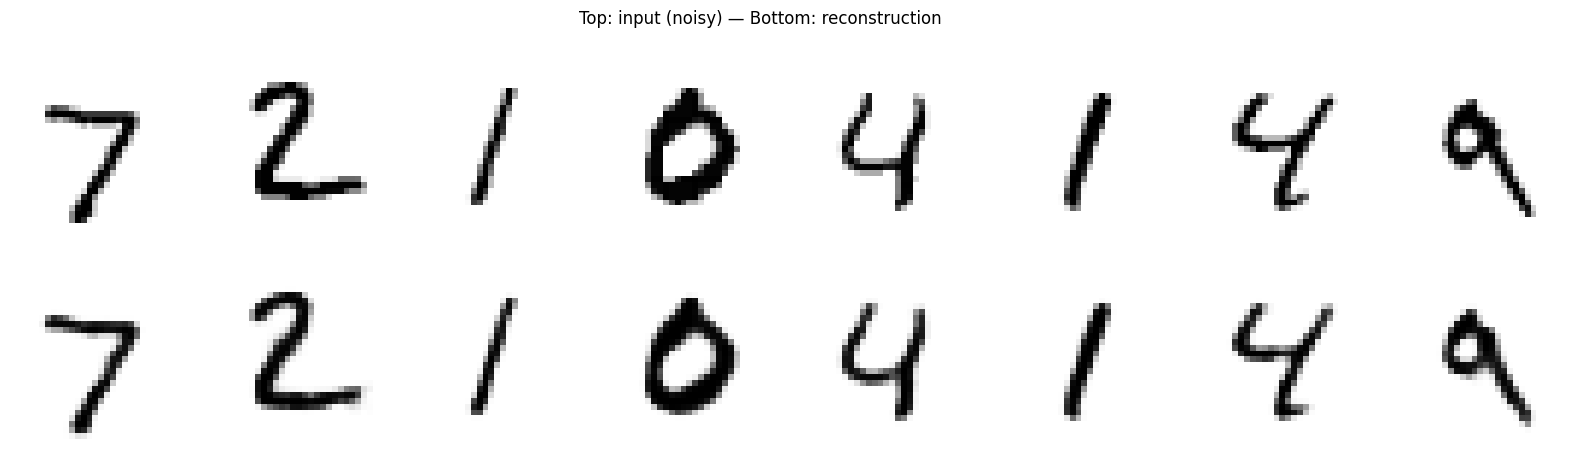

In [26]:
# Visualize reconstructions from the convolutional autoencoder
stacked_autoencoder.eval()

plt.figure(figsize=(20, 5))
for i in range(8):
    plt.subplot(2, 8, i + 1)
    with torch.no_grad():
        inp = torch.tensor(x_test[i]).reshape(1, 28, 28).to(device)
        pred = stacked_autoencoder(inp).cpu().numpy()
    plt.imshow(x_test[i], cmap="binary")
    plt.axis("off")

    plt.subplot(2, 8, i + 8 + 1)
    plt.imshow(pred.reshape((28, 28)), cmap="binary")
    plt.axis("off")
plt.suptitle("Top: input (noisy) — Bottom: reconstruction")
plt.show()

# Final Questions

Answer these global questions at the end of the lab:

1. What is the purpose of each major stage of the notebook?
   - loading the data
   - simple dense autoencoder
   - denoising autoencoder
   - convolutional autoencoder
   - reconstruction analysis

2. What is an autoencoder, and how is it different from a classifier?

3. What is the role of the bottleneck or latent vector?

4. Why do we train an autoencoder with the input and target equal to each other?

5. Why can a denoising autoencoder be useful?

6. Why are convolutional layers often better than dense layers for image reconstruction?

7. What does the latent shape `1 × 64 × 3 × 3` mean in the convolutional autoencoder? *(Note the PyTorch channel-first ordering vs. the `1 × 3 × 3 × 64` shown in the original Keras notebook — same values, different axis order.)*

8. How do you judge whether a reconstruction is good?

9. What are the main limitations of these models?

10. What would you try next to improve the reconstructions?

11. What practical differences did you notice between the Keras and PyTorch versions (e.g. `Sequential` composition of an encoder/decoder into one model, explicit training loop, `BCELoss` vs the decoder's own `Sigmoid`, channel ordering `NCHW` vs `NHWC`)?

# Answer

1. Purpose of each major stage of the notebook:

* **Loading the data:** To prepare the MNIST dataset. The pixel values are normalized to be between 0 and 1.

* **Simple dense autoencoder:** To introduce the basic concept of an autoencoder, demonstrating how a neural network can compress an input into a latent representation and then reconstruct the original input using only fully connected (dense) layers.

* **Denoising autoencoder:** To illustrate how autoencoders can be trained to remove noise from images. The model learns to reconstruct a clean image from a noisy input.

* **Convolutional autoencoder:** To show how convolutional layers, which are typically better suited for image processing, can be used in autoencoders to preserve spatial structure and potentially achieve better reconstruction quality.

* **Reconstruction analysis:** To visually assess the quality of the images reconstructed by the trained autoencoders and to understand how much information is retained in the bottleneck representation.

2. An autoencoder is a type of neural network that learns to compress input data into a lower-dimensional latent representation and then reconstruct the original input from this representation. It's an unsupervised or self-supervised learning model. It differs from a classifier in its objective: a classifier learns to map input data to discrete class labels (e.g., identifying a digit as '0' or '1'), whereas an autoencoder learns to reconstruct its input, effectively learning a useful representation of the data itself without explicit labels.

3. The bottleneck (or latent vector/representation) is the compressed, low-dimensional encoding of the input data. Its role is to capture the most essential features and information of the input in a compact form. This compression forces the autoencoder to learn a meaningful representation, as it must discard less important information to successfully reconstruct the original input from this limited representation.

4. We train an autoencoder with the input and target equal to each other because the goal of an autoencoder is to learn an identity function, but with a constraint: it must pass through a bottleneck. By setting the input and target to be the same, the network learns to reconstruct its own input, which compels it to discover efficient data representations in the bottleneck layer.

5. A denoising autoencoder can be useful for several reasons:

* Noise reduction: It can effectively remove noise from corrupted data, producing cleaner versions of the input.
* Robust feature learning: By forcing the model to recover the original input from a noisy version, it learns more robust and meaningful features that are less susceptible to input perturbations.
* Data cleaning/preprocessing: It can serve as a powerful preprocessing step for other machine learning tasks by providing cleaned or denoised data.

6. Convolutional layers are generally better than dense layers for image reconstruction because:

* Spatial structure preservation: They inherently capture local spatial relationships and patterns within an image (e.g., edges, textures) due to their use of filters and local receptive fields. Dense layers, after flattening the image, lose this spatial context.
* Parameter efficiency: Convolutional layers often require fewer parameters compared to dense layers for processing images, especially when dealing with high-resolution images, leading to more efficient models and reduced overfitting.
* Translation invariance: Convolutional operations are naturally somewhat invariant to the translation of features within an image, meaning they can detect a feature regardless of its exact position.

7. The latent shape 1 × 64 × 3 × 3 in the convolutional autoencoder refers to the dimensions of the bottleneck representation after the encoder processes an image. In PyTorch's channel-first convention (NCHW), this means:

* 1: The batch size (assuming a single image is processed at a time).
* 64: The number of feature channels or filters at the bottleneck layer. Each of these 64 channels holds a different learned feature map.
* 3 × 3: The spatial dimensions (height and width) of each of these 64 feature maps. So, each feature map is a small 3x3 grid of values. In essence, it means the original 28x28 image has been compressed into 64 distinct 3x3 feature maps.

8. You judge whether a reconstruction is good primarily by:

* Visual inspection: The most straightforward way is to visually compare the reconstructed image with the original. A good reconstruction should be perceptually similar to the original, retaining important details and overall structure.
* Reconstruction loss: Quantitatively, a lower reconstruction loss (e.g., Binary Cross-Entropy in this case) indicates better reconstruction. This metric measures the difference between the original and reconstructed inputs.
* Preservation of semantic content: A good reconstruction should preserve the semantic meaning or identity of the original input. For instance, if the input is a digit '7', the reconstructed image should still clearly look like a '7'.

9. Main limitations include:

* Reconstruction quality: While they reconstruct the training data well, they might struggle with completely novel inputs or generalize poorly to data significantly different from the training distribution.
* Blurriness: Reconstructed images, especially from simpler autoencoders, can often appear blurry or lacking fine details.
* Mode collapse (in some advanced variants): While not directly applicable to simple autoencoders, generative autoencoder variants can suffer from mode collapse, where they fail to capture the full diversity of the input data.
* Not truly generative (basic autoencoders): Standard autoencoders are not designed to generate new, never-before-seen data that differs significantly from the training set; they excel at reproducing what they've seen.

10.  To improve reconstructions, I would try:

* Deeper or wider architectures: Experiment with more layers or more neurons per layer in the encoder and decoder.
* Different activation functions: Explore LeakyReLU, ELU, or GELU instead of just ReLU.
* Regularization techniques: Implement L1/L2 regularization, dropout, or batch normalization to prevent overfitting and improve generalization.
* Variational Autoencoders (VAEs): For more robust and generative capabilities, switch to VAEs, which learn a distribution over the latent space.
* Loss function adjustments: Explore perceptual losses or structural similarity index (SSIM) in addition to or instead of BCE for potentially better visual quality.
* Increased training epochs or different optimizers: Train for longer or use optimizers like RMSprop or AdamW.
* More sophisticated noise models: For denoising autoencoders, experiment with different types or levels of noise.

11. Based on the notebook's implementation and general PyTorch practices:

* Sequential composition of an encoder/decoder into one model: Both Keras (tf.keras.Model) and PyTorch (nn.Module) allow for composing models sequentially, making it a similar high-level approach.
* Explicit training loop: PyTorch typically requires a more explicit manual training loop (iterating over epochs, batches, forward pass, loss calculation, backward pass, optimizer step), whereas Keras provides a high-level model.fit() method that abstracts much of this away.
* BCELoss vs. the decoder's own Sigmoid: In PyTorch, nn.BCELoss expects probabilities (values between 0 and 1), so the decoder's output layer must include a Sigmoid activation. If the decoder outputs raw logits, nn.BCEWithLogitsLoss would be used instead, which internally applies sigmoid for numerical stability.
* Channel ordering NCHW vs. NHWC: PyTorch uses a channel-first convention (Batch, Channels, Height, Width - NCHW) for convolutional layers, while Keras/TensorFlow often defaults to channel-last (NHWC). This requires unsqueeze(1) on the input for the PyTorch encoder and squeeze(1) on the output of the PyTorch decoder to handle the channel dimension for grayscale images. This also affects how latent shapes are interpreted (e.g., 1x64x3x3 in PyTorch vs. 1x3x3x64 in Keras for the same bottleneck).